In [23]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from matplotlib.lines import Line2D

In [24]:
# ── Configuration ──────────────────────────────────────────────────────────
ROOT = Path("..")  # repo root (notebook lives in plotting_notebooks/)

# Directories used to read closest_meci labels (always multi_ref)
LABEL_DIRS = {
    "ethylene":     ROOT / "data/ethylene/aligned_spawns/multi_ref",
    "butadiene_s0": ROOT / "data/butadiene_s0/aligned_spawns/multi_ref",
    "butadiene_s1": ROOT / "data/butadiene_s1/aligned_spawns/multi_ref",
    "benzene_s0":   ROOT / "data/benzene_s0/aligned_spawns/multi_ref",
    "benzene_s1":   ROOT / "data/benzene_s1/aligned_spawns/multi_ref",
}

DIM_RED_DIR = ROOT / "dim_red_analysis"

METHODS = ["PCA", "tSNE", "UMAP", "densMAP", "DiffusionMap", "Isomap", "LaplacianEigenmaps"]

METRICS = ["trustworthiness", "continuity", "spearman_dist_corr", "density_spearman", "stress"]

# Set to a percentile value (e.g. 1.0) to clip axis limits to [p, 100-p] percentile
# and avoid outliers dominating the plot scale. Set to None for no clipping.
CLIP_PERCENTILE = None
#CLIP_PERCENTILE = 0.1

In [25]:
# ── Helpers ────────────────────────────────────────────────────────────────

def load_meci_labels(xyz_dir: Path):
    """Read closest_meci from XYZ comment lines; returns list of labels in sorted filename order."""
    labels = []
    for fpath in sorted(xyz_dir.glob("*.xyz")):
        with open(fpath) as f:
            lines = f.readlines()
        comment = lines[1] if len(lines) > 1 else ""
        m = re.search(r"closest_meci=(\S+)", comment)
        labels.append(m.group(1).replace(".xyz", "") if m else "unknown")
    return labels


def labels_to_colors(labels):
    """Map string labels to integer indices and a colour array."""
    unique = sorted(set(labels))
    palette = cm.get_cmap("tab20", len(unique))
    lut = {lab: i for i, lab in enumerate(unique)}
    indices = np.array([lut[l] for l in labels])
    colors  = palette(indices / max(len(unique) - 1, 1))
    return indices, unique, colors, palette


def load_embedding(dataset: str, method: str):
    path = DIM_RED_DIR / dataset / f"{method}_embedding.npy"
    if path.exists():
        return np.load(path)
    return None

Plotting embeddings for ethylene ...


/var/folders/r5/bdk9tylx4kn181q9bvcflv7h0000gn/T/ipykernel_7418/2074275588.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Spectral")


  Saved → ../dim_red_analysis/ethylene/embeddings_2d.png
  Saved → ../dim_red_analysis/ethylene/embeddings_2d.svg


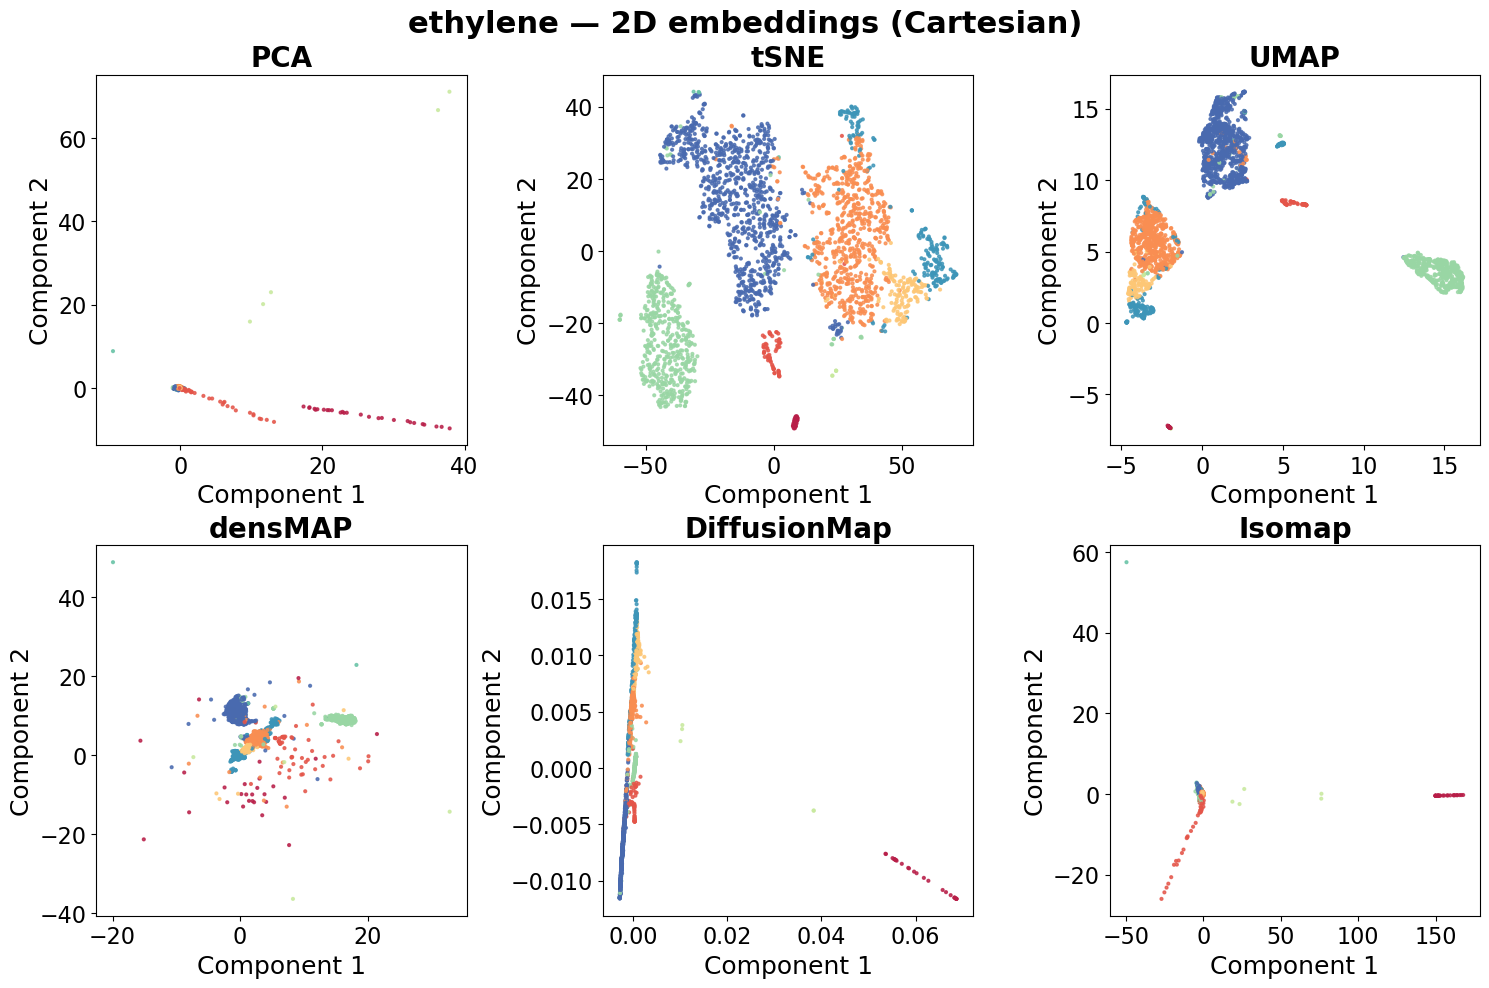

Plotting embeddings for butadiene_s0 ...
  Saved → ../dim_red_analysis/butadiene_s0/embeddings_2d.png
  Saved → ../dim_red_analysis/butadiene_s0/embeddings_2d.svg


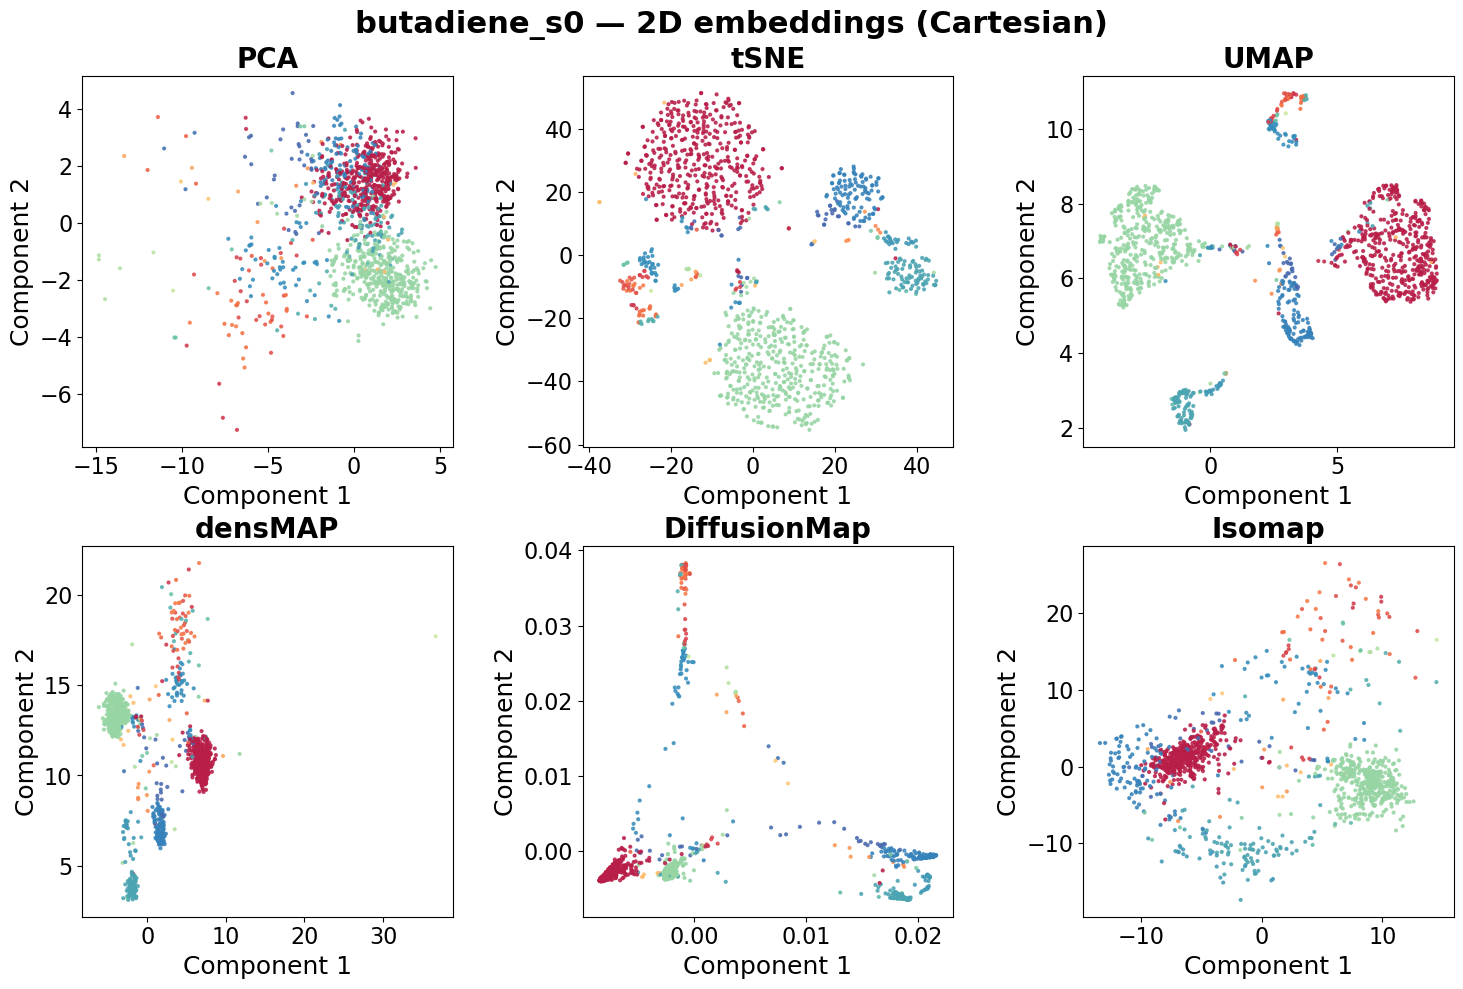

Plotting embeddings for butadiene_s1 ...
  Saved → ../dim_red_analysis/butadiene_s1/embeddings_2d.png
  Saved → ../dim_red_analysis/butadiene_s1/embeddings_2d.svg


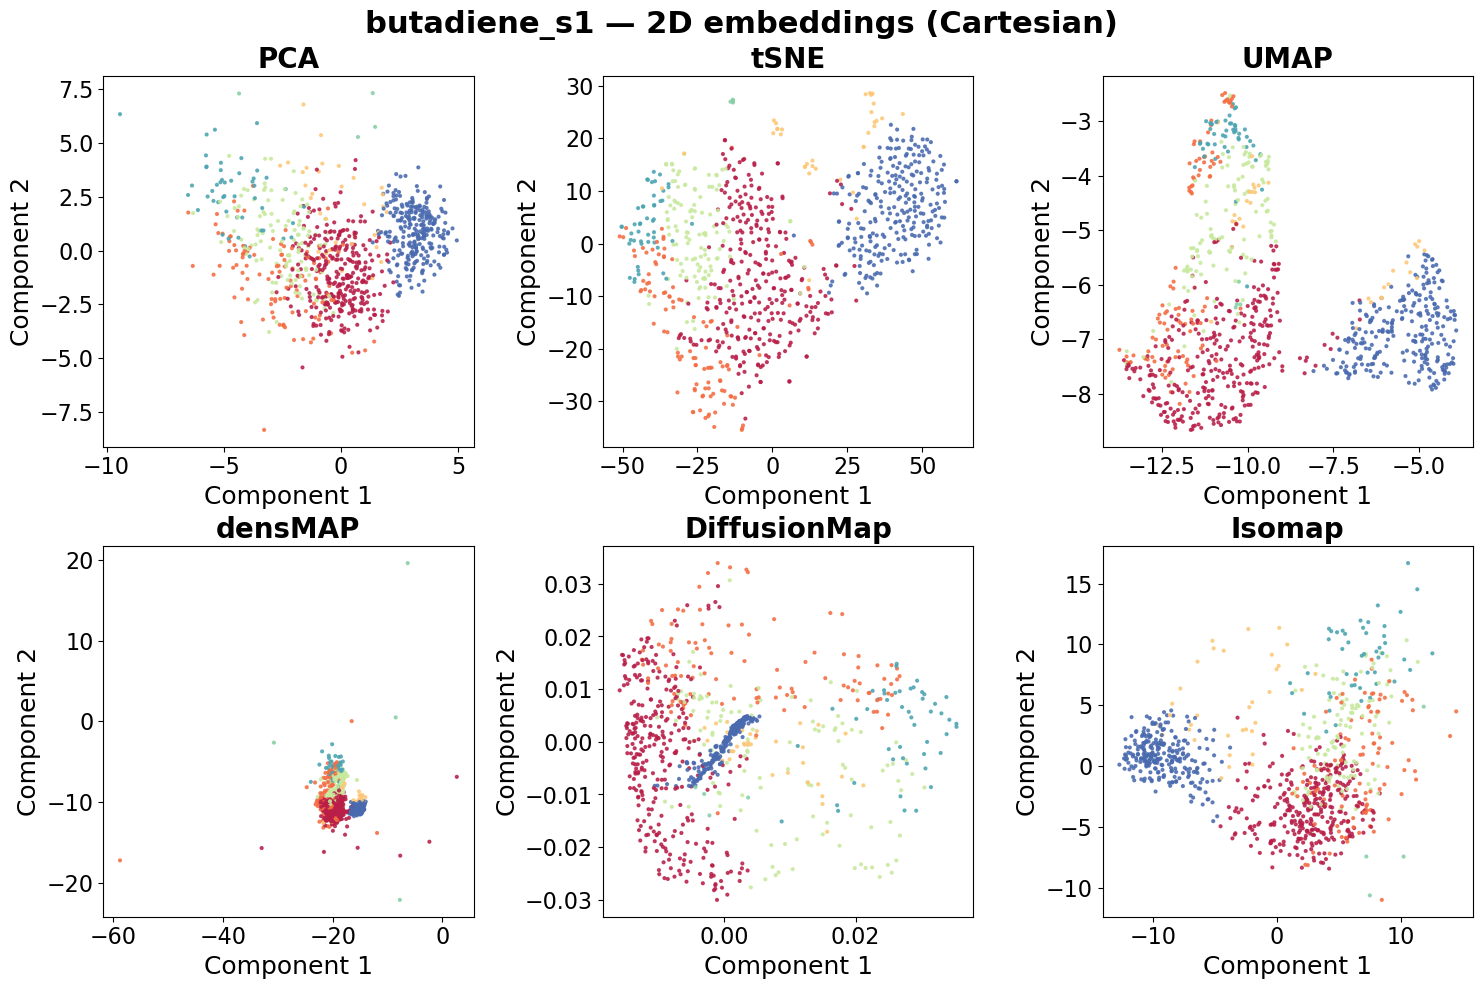

Plotting embeddings for benzene_s0 ...
  Saved → ../dim_red_analysis/benzene_s0/embeddings_2d.png
  Saved → ../dim_red_analysis/benzene_s0/embeddings_2d.svg


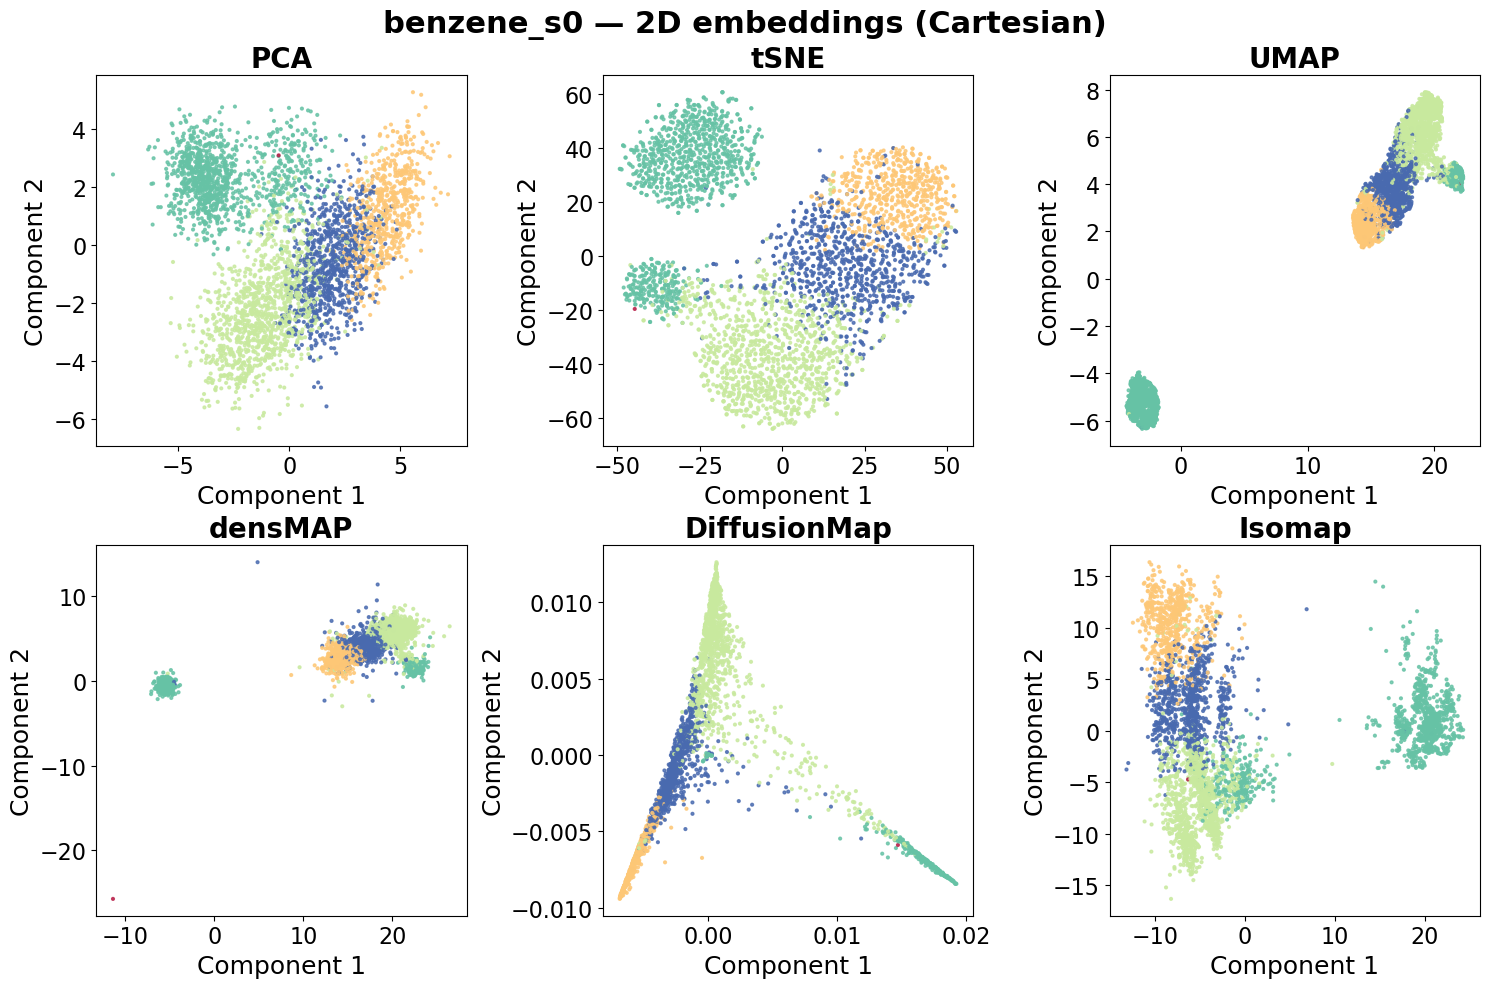

Plotting embeddings for benzene_s1 ...
  Saved → ../dim_red_analysis/benzene_s1/embeddings_2d.png
  Saved → ../dim_red_analysis/benzene_s1/embeddings_2d.svg


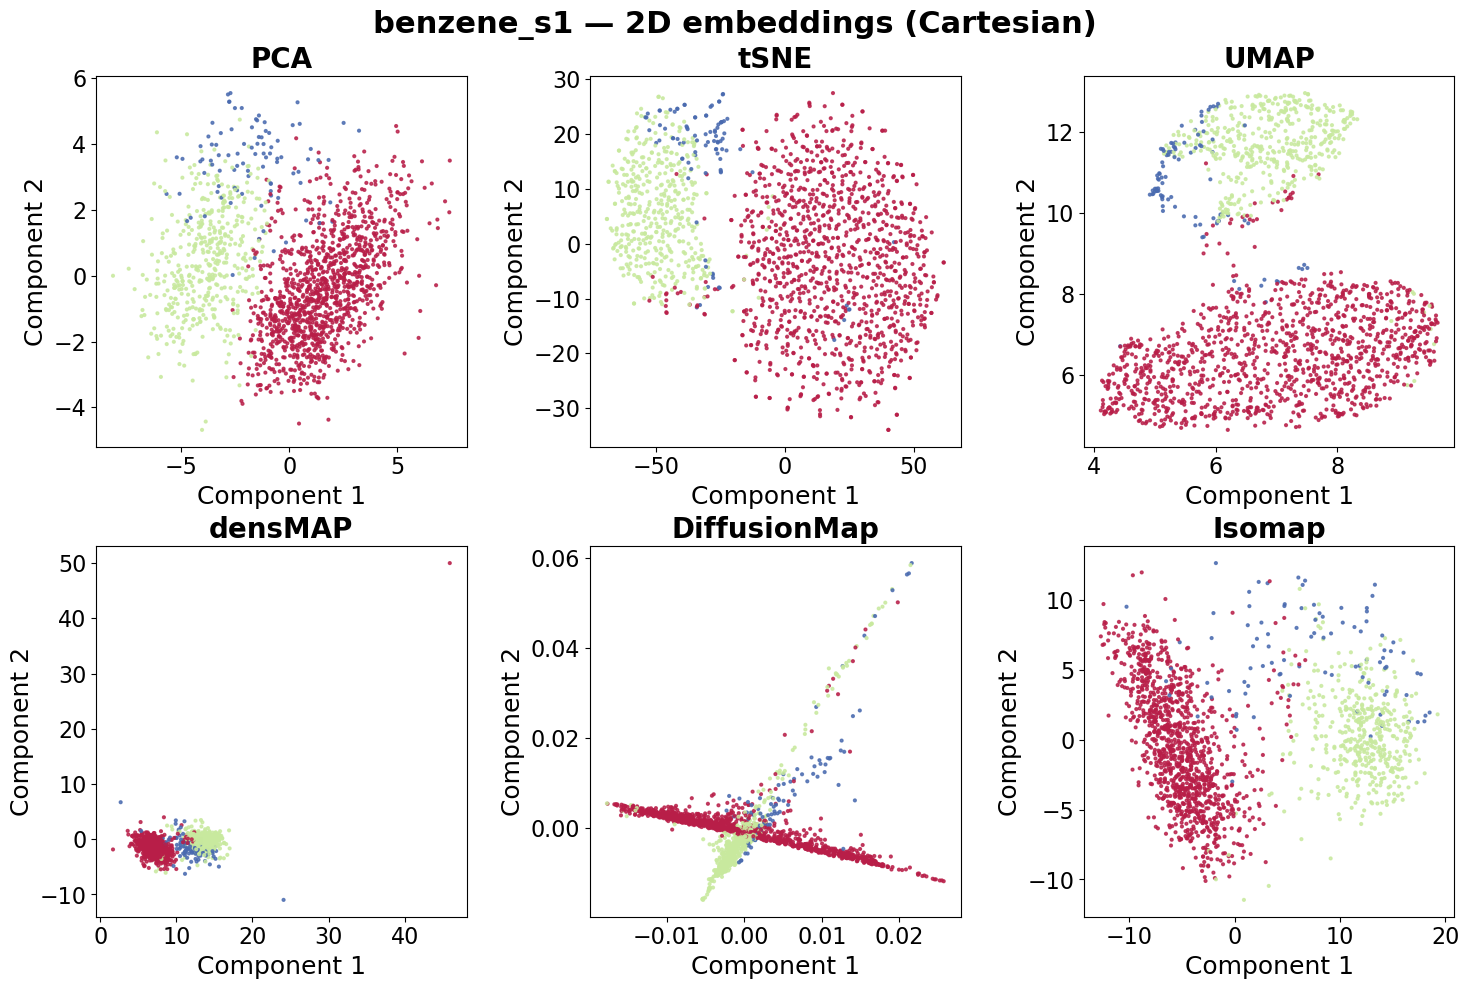

In [29]:
# ── 2-D scatter plots: one figure per dataset, 6 subplots (2×3) ──

SCATTER_METHODS = ["PCA", "tSNE", "UMAP", "densMAP", "DiffusionMap", "Isomap"]

def make_palette(n):
    cmap = cm.get_cmap("Spectral")

    # split sampling to avoid yellow (~0.4–0.6)
    n1 = n // 2
    n2 = n - n1

    vals = list(np.linspace(0.05, 0.35, n1)) + \
           list(np.linspace(0.65, 0.95, n2))

    return [cmap(v) for v in vals]

for dataset in LABEL_DIRS:
    print(f"Plotting embeddings for {dataset} ...")

    labels = load_meci_labels(LABEL_DIRS[dataset])
    unique_labels = sorted(set(labels))
    palette_colors = make_palette(len(unique_labels))
    lut = {lab: c for lab, c in zip(unique_labels, palette_colors)}
    colors = [lut[l] for l in labels]

    panel_size = 5  # inches per panel
    fig, axes = plt.subplots(2, 3,
                             figsize=(3 * panel_size, 2 * panel_size),
                             subplot_kw={"box_aspect": 1})
    axes = axes.flatten()

    for ax, method in zip(axes, SCATTER_METHODS):
        emb = load_embedding(dataset, method)
        if emb is None:
            ax.set_visible(False)
            continue

        ax.scatter(emb[:, 0], emb[:, 1], s=4, alpha=0.8, c=colors, rasterized=True)
        ax.set_title(method, fontsize=20, fontweight="bold")
        ax.set_xlabel("Component 1", fontsize=18)
        ax.set_ylabel("Component 2", fontsize=18)
        ax.tick_params(labelsize=16)

        if CLIP_PERCENTILE is not None:
            p = CLIP_PERCENTILE
            ax.set_xlim(np.percentile(emb[:, 0], p), np.percentile(emb[:, 0], 100 - p))
            ax.set_ylim(np.percentile(emb[:, 1], p), np.percentile(emb[:, 1], 100 - p))

    fig.suptitle(f"{dataset} — 2D embeddings (Cartesian)", fontsize=22, fontweight="bold")
    plt.tight_layout()

    for ext, dpi in [("png", 300), ("svg", 300)]:
        out = DIM_RED_DIR / dataset / f"embeddings_2d.{ext}"
        plt.savefig(out, dpi=dpi, bbox_inches="tight")
        print(f"  Saved → {out}")

    plt.show()

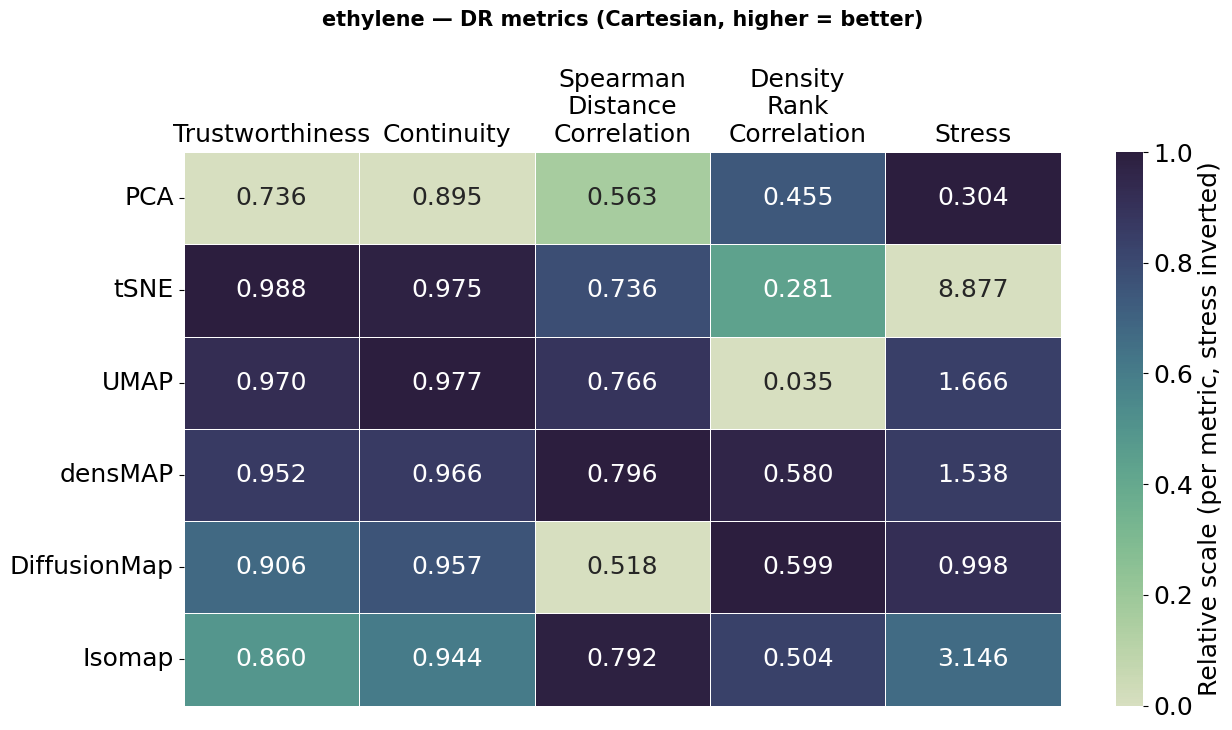

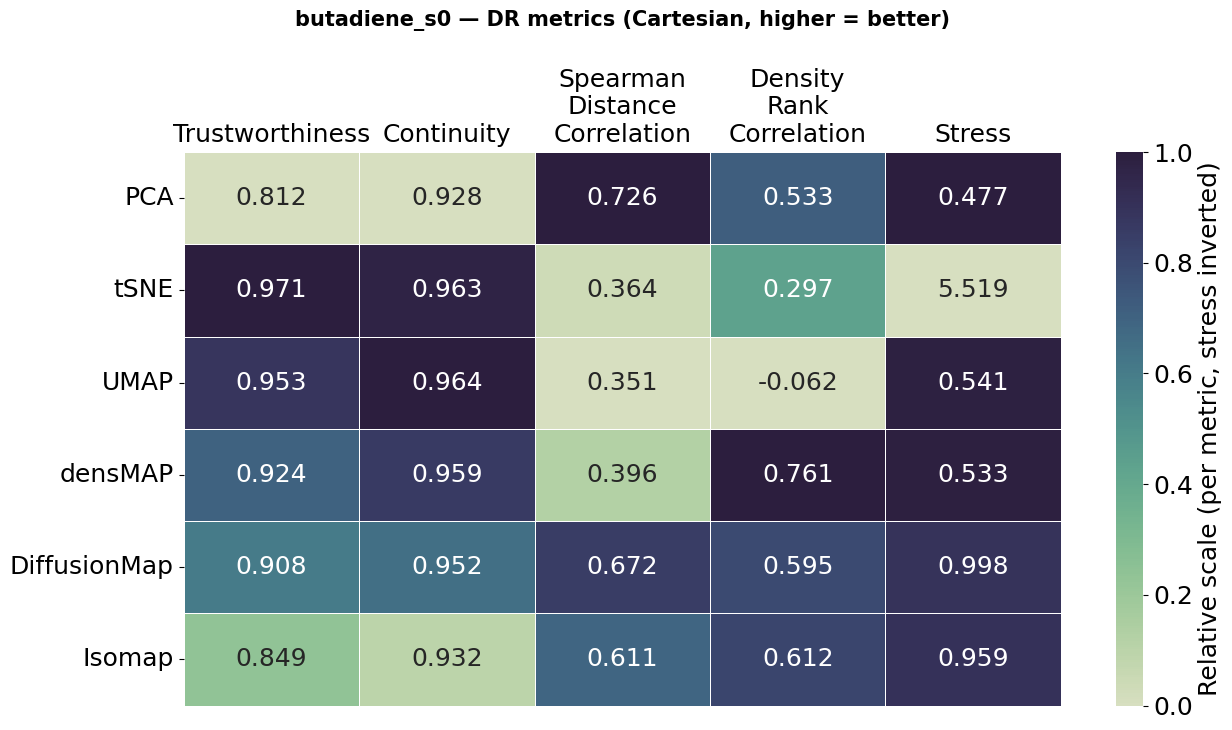

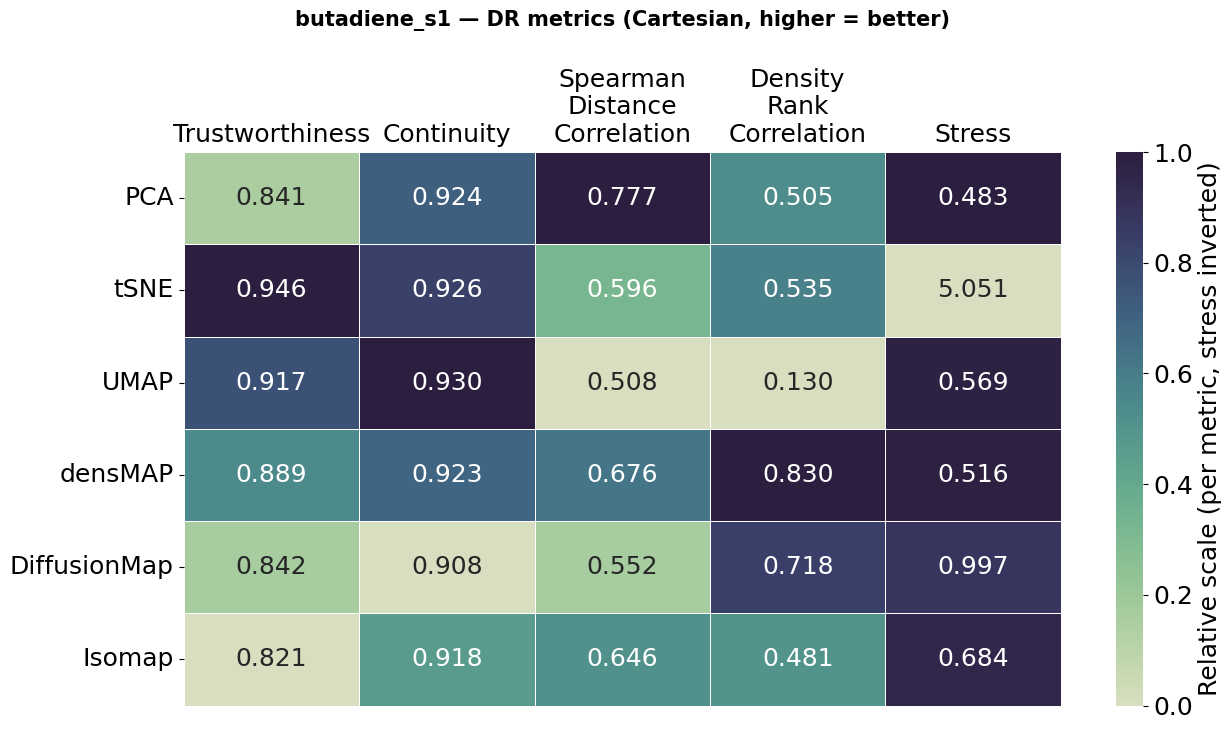

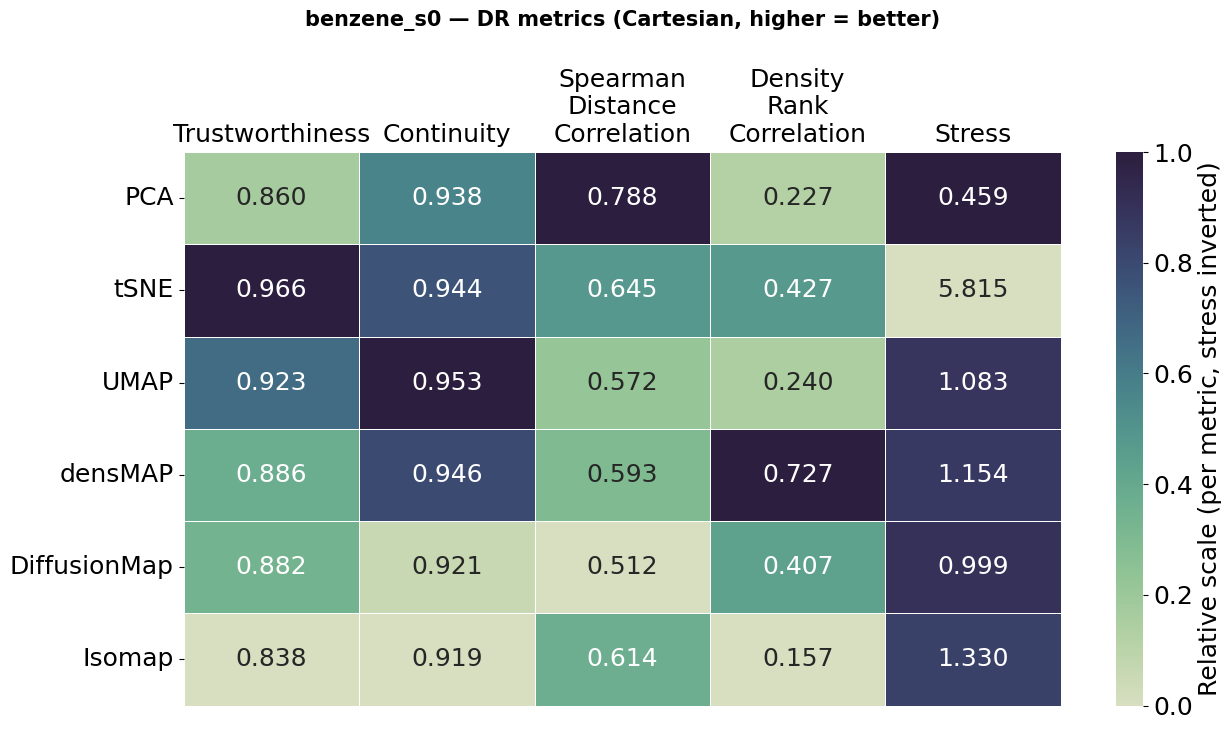

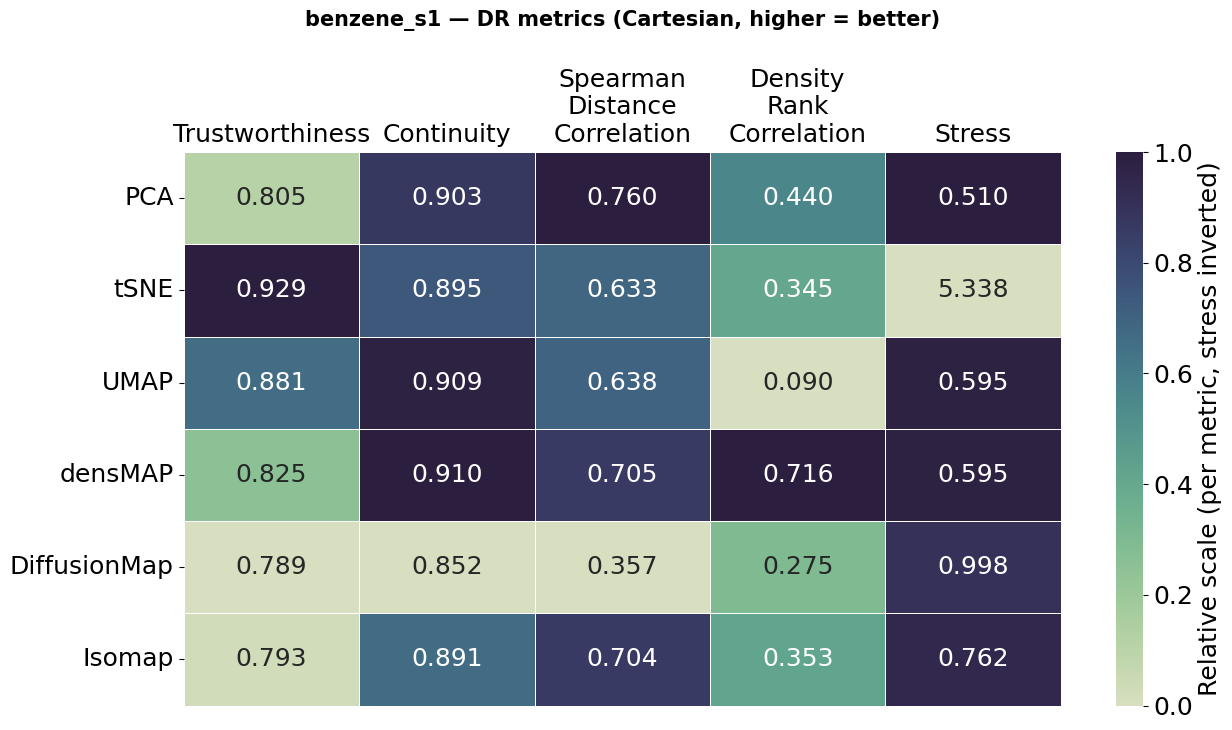

In [33]:
# ── Metrics heatmap: one figure per dataset ────────────────────────────────

INVERT       = {"stress"}
DROP_METHODS = {"LaplacianEigenmaps"}

METRIC_LABELS = {
    "trustworthiness":    "Trustworthiness",
    "continuity":         "Continuity",
    "spearman_dist_corr": "Spearman\nDistance\nCorrelation",
    "stress":             "Stress",
    "density_spearman":   "Density\nRank\nCorrelation",
}

HEATMAP_CMAP = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True)

for dataset in LABEL_DIRS:
    csv_path = DIM_RED_DIR / dataset / "metrics.csv"
    if not csv_path.exists():
        print(f"  No metrics.csv for {dataset}, skipping.")
        continue

    df = pd.read_csv(csv_path).set_index("method")
    df = df.drop(index=[m for m in DROP_METHODS if m in df.index])
    available = [m for m in METRICS if m in df.columns]
    df = df[available]

    norm = df.copy()
    for col in norm.columns:
        lo, hi = norm[col].min(), norm[col].max()
        norm[col] = (norm[col] - lo) / (hi - lo) if hi != lo else 0.5
        if col in INVERT:
            norm[col] = 1 - norm[col]

    col_labels = [METRIC_LABELS.get(m, m) for m in available]
    norm.columns = col_labels
    df_annot = df.copy()
    df_annot.columns = col_labels

    col_width = 2.4
    fig, ax = plt.subplots(figsize=(len(available) * col_width + 1, len(df) * 0.9 + 2))
    sns.heatmap(
        norm,
        annot=df_annot.round(3),
        fmt=".3f",
        cmap=HEATMAP_CMAP,
        linewidths=0.5,
        ax=ax,
        annot_kws={"size": 18},
        cbar_kws={"label": "Relative scale (per metric, stress inverted)"},
    )
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=18)
    cbar.set_label("Relative scale (per metric, stress inverted)", size=18)
    ax.set_title(f"{dataset} — DR metrics (Cartesian, higher = better)",
                 fontsize=15, fontweight="bold", pad=30)
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=18, length=0)
    ax.tick_params(axis="y", labelsize=18, rotation=0)
    plt.tight_layout()
    plt.savefig(DIM_RED_DIR / dataset / "metrics_heatmap.png", dpi=300, bbox_inches="tight")
    plt.savefig(DIM_RED_DIR / dataset / "metrics_heatmap.svg", dpi=300, bbox_inches="tight")
    plt.show()

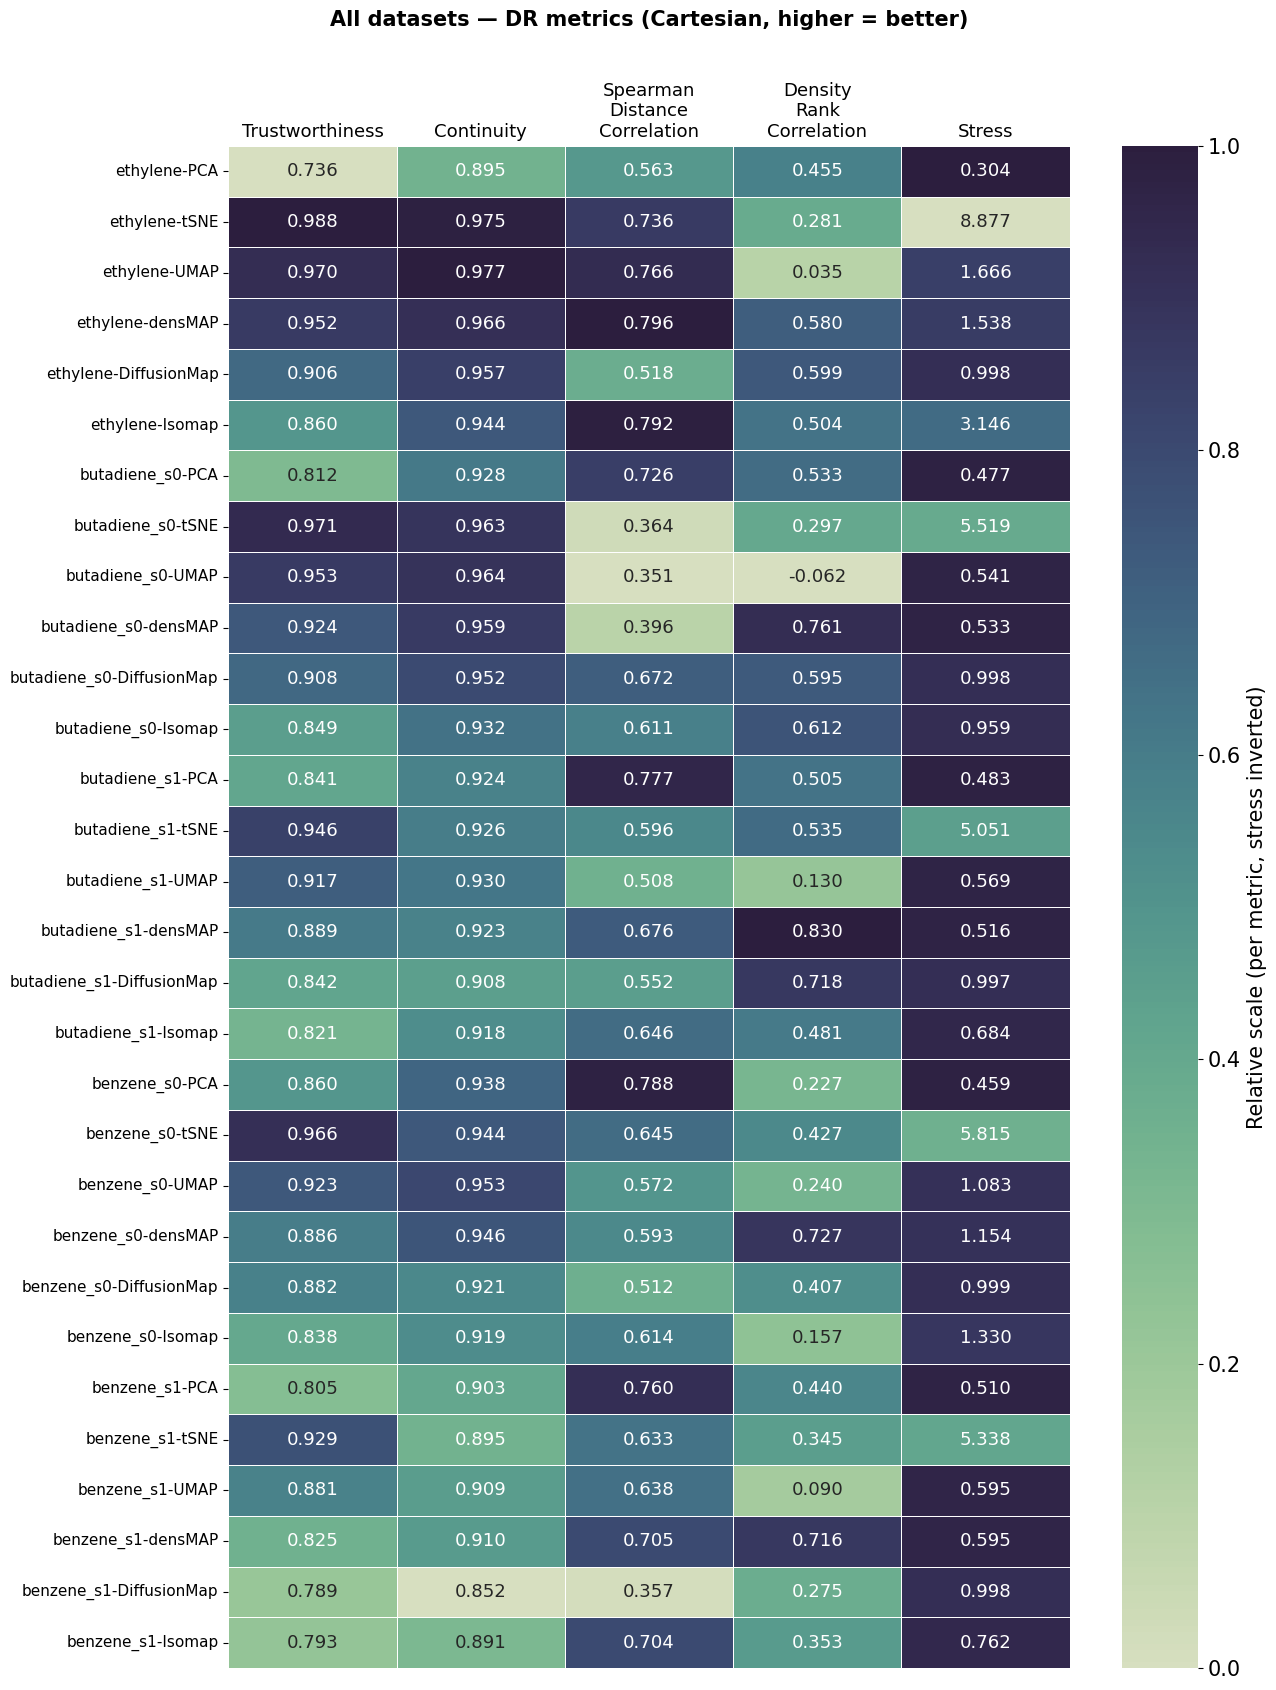

Saved → ../dim_red_analysis/combined_metrics_heatmap.png


In [28]:
# ── Combined heatmap: all datasets ─────────────────────────────────────────

all_dfs = []
for dataset in LABEL_DIRS:
    csv_path = DIM_RED_DIR / dataset / "metrics.csv"
    if not csv_path.exists():
        continue
    df = pd.read_csv(csv_path)
    df = df[~df["method"].isin(DROP_METHODS)]
    df["dataset"] = dataset
    all_dfs.append(df)

combined = pd.concat(all_dfs, ignore_index=True)
combined = combined.set_index(["dataset", "method"])
available = [m for m in METRICS if m in combined.columns]
combined = combined[available]

norm = combined.copy()
for col in norm.columns:
    lo, hi = norm[col].min(), norm[col].max()
    norm[col] = (norm[col] - lo) / (hi - lo) if hi != lo else 0.5
    if col in INVERT:
        norm[col] = 1 - norm[col]

col_labels = [METRIC_LABELS.get(m, m) for m in available]
norm.columns = col_labels
combined_annot = combined.copy()
combined_annot.columns = col_labels

col_width = 2.4
fig, ax = plt.subplots(figsize=(len(available) * col_width + 1, len(combined) * 0.5 + 2))
sns.heatmap(
    norm,
    annot=combined_annot.round(3),
    fmt=".3f",
    cmap=HEATMAP_CMAP,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 13},
    cbar_kws={"label": "Relative scale (per metric, stress inverted)"},
)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=15)
cbar.set_label("Relative scale (per metric, stress inverted)", size=15)
ax.set_title("All datasets — DR metrics (Cartesian, higher = better)",
             fontsize=15, fontweight="bold", pad=40)
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=13, length=0)
ax.tick_params(axis="y", labelsize=11, rotation=0)
plt.tight_layout()
plt.savefig(DIM_RED_DIR / "combined_metrics_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {DIM_RED_DIR / 'combined_metrics_heatmap.png'}")